# 05 — Evaluation
**Goal:** Load the best model (MLP), evaluate on test data, plot confusion matrix, and print classification report.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Imports done ✅")

Imports done ✅


## 2. Load Best Model and Scaler

In [2]:
# Read best model name
with open('best_model_name.txt', 'r') as f:
    best_model_name = f.read().strip()

print(f"Best model: {best_model_name}")

# Load scaler
scaler = joblib.load('scaler.pkl')
print("Loaded: scaler.pkl")

# Load best model
if best_model_name == 'CNN':
    from tensorflow.keras.models import load_model
    model = load_model('best_model.h5')
else:
    model = joblib.load('best_model.pkl')

print(f"Loaded: best_model — {best_model_name} ✅")

Best model: MLP
Loaded: scaler.pkl
Loaded: best_model — MLP ✅


## 3. Recreate Test Set

In [3]:
EMOTION_LABELS = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']

# Load features
df = pd.read_csv('features.csv')
X  = df.drop('label', axis=1).values
y  = df['label'].values

# Apply same scaling
X_scaled = scaler.transform(X)

# Recreate exact same splits using same random_state=42
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)

print(f"Test set size: {X_test.shape[0]} samples")
print("Test set recreated ✅")

Test set size: 848 samples
Test set recreated ✅


## 4. Predictions

In [4]:
if best_model_name == 'CNN':
    from tensorflow.keras.utils import to_categorical
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    y_pred = np.argmax(model.predict(X_test_cnn), axis=1)
else:
    y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 89.62%


## 5. Classification Report

In [5]:
print("=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=EMOTION_LABELS
))

=== Classification Report ===
              precision    recall  f1-score   support

     neutral       0.86      0.95      0.90       138
       happy       0.91      0.87      0.89       118
         sad       0.84      0.85      0.84       118
       angry       0.91      0.94      0.93       118
        fear       0.91      0.91      0.91       119
     disgust       0.91      0.87      0.89       119
    surprise       0.95      0.88      0.91       118

    accuracy                           0.90       848
   macro avg       0.90      0.89      0.90       848
weighted avg       0.90      0.90      0.90       848



## 6. Confusion Matrix

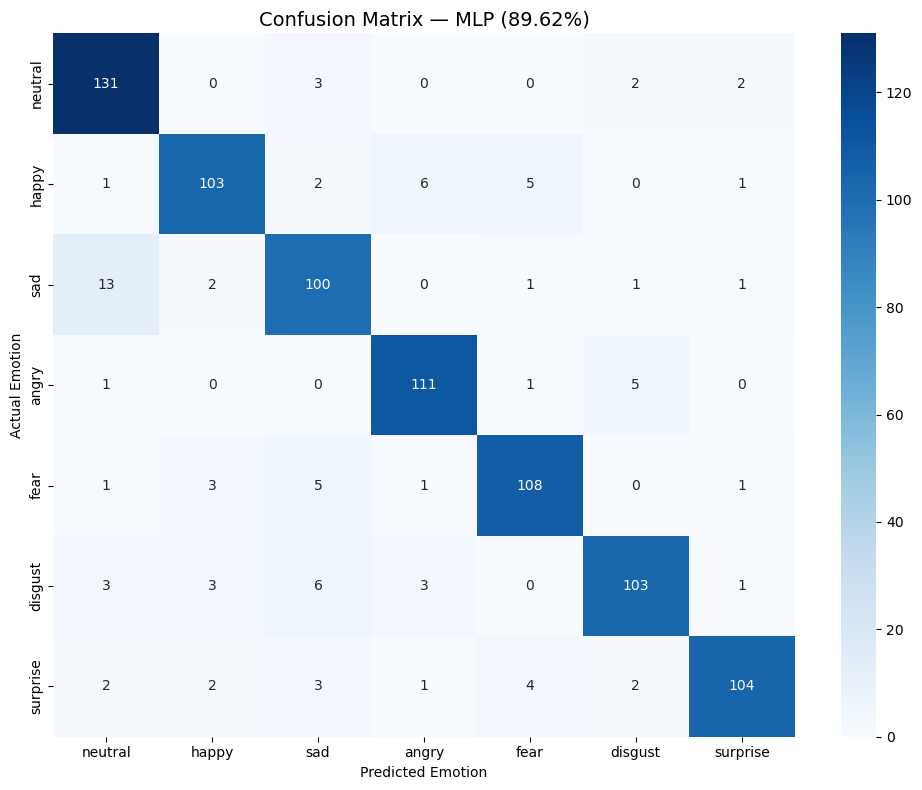

Saved: confusion_matrix.png


In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=EMOTION_LABELS,
    yticklabels=EMOTION_LABELS
)
plt.title(f'Confusion Matrix — {best_model_name} ({accuracy*100:.2f}%)', fontsize=14)
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## 7. Per Emotion Accuracy

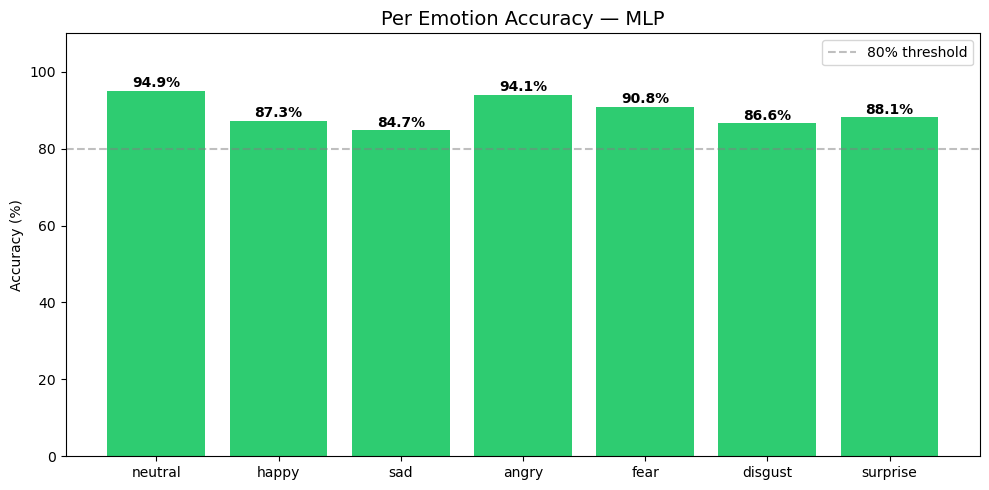

Saved: per_emotion_accuracy.png

Per Emotion Accuracy:
  neutral    94.93%
  happy      87.29%
  sad        84.75%
  angry      94.07%
  fear       90.76%
  disgust    86.55%
  surprise   88.14%


In [7]:
per_emotion_acc = cm.diagonal() / cm.sum(axis=1) * 100

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if a >= 80 else '#e67e22' if a >= 60 else '#e74c3c' for a in per_emotion_acc]
bars = plt.bar(EMOTION_LABELS, per_emotion_acc, color=colors)
plt.title(f'Per Emotion Accuracy — {best_model_name}', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim([0, 110])
for bar, acc in zip(bars, per_emotion_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('per_emotion_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_emotion_accuracy.png')

print("\nPer Emotion Accuracy:")
for emotion, acc in zip(EMOTION_LABELS, per_emotion_acc):
    print(f"  {emotion:<10} {acc:.2f}%")

---
**Done!** Evaluation complete. Next step → `06_demo.ipynb`